### IMS Bearing Dataset — Preprocessing Pipeline
**Thesis:** Bayesian ML for Real-Time RUL Prediction of Industrial Rotating Equipment

> **Scope:** test2 + test3 only


### 1. Imports & Paths

In [2]:
import os
import glob
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
warnings.filterwarnings('ignore')

from pathlib import Path
from datetime import datetime
from concurrent.futures import ThreadPoolExecutor, as_completed

from scipy.stats import skew, kurtosis, spearmanr
from scipy.signal import butter, hilbert
from scipy import signal as sp_signal
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Paths to the 3 IMS test runs (update BASE_DIR to your local data folder)
BASE_DIR = r"C:\Users\Windown\OneDrive\1_Dissertation\1_Project_Dissertation"
TEST_DIRS = {
    'test1': os.path.join(BASE_DIR, '1st_test'),   # used later for robustness testing
    'test2': os.path.join(BASE_DIR, '2nd_test'),
    'test3': os.path.join(BASE_DIR, '3rd_test'),
}
OUTPUT_DIR = './preprocessing_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# test1 is loaded later, on-demand (see process_test1_for_robustness at the bottom)
ACTIVE_TESTS = ['test2', 'test3']

# Failure bearing/channels per test run:
# test1: B3 inner race + B4 roller (8 columns) | test2: B1 outer race (4 columns) | test3: B3 outer race (4 columns)
TEST_META = {
    'test1': {'failure_bearings': [2, 3], 'failure_modes': ['inner_race', 'roller'],
              'n_channels': 8, 'ch_map': [0, 2, 4, 6]},
    'test2': {'failure_bearings': [0],    'failure_modes': ['outer_race'],
              'n_channels': 4, 'ch_map': [0, 1, 2, 3]},
    'test3': {'failure_bearings': [2],    'failure_modes': ['outer_race'],
              'n_channels': 4, 'ch_map': [0, 1, 2, 3]},
}
FAILURE_IDX = {'test1': 2, 'test2': 0, 'test3': 2}

# Signal constants
FS       = 20_000
N_POINTS = 20_480
BEARINGS = ['Bearing1', 'Bearing2', 'Bearing3', 'Bearing4']

# Fault frequencies (Rexnord ZA-2115, 2000 RPM)
BPFO, BPFI, BSF, FTF = 236.4, 296.9, 139.9, 14.78

HEALTHY_N = 200   # samples assumed healthy for scaler/PCA fitting

# Verify active paths only
print("Checking active dataset directories (test2 + test3)...")
for name in ACTIVE_TESTS:
    path = TEST_DIRS[name]
    if os.path.exists(path):
        n = len(glob.glob(os.path.join(path, "*.*.*.*.*.*")))
        print(f"  {name}: {n} files  ({TEST_META[name]['n_channels']} channels/file)")
    else:
        print(f"  NOT FOUND: {path}")

Checking active dataset directories (test2 + test3)...
  test2: 984 files  (4 channels/file)
  test3: 6324 files  (4 channels/file)


### 2. Feature Extraction Functions

In [3]:
def bandpass_filter(data, lowcut, highcut, fs=FS, order=4):
    # Bandpass filter (sosfilt, stable at high cutoffs, not zero-phase).
    # lowcut/highcut are chosen per test run via the kurtogram (Section 2b).
    sos = butter(order, [lowcut, highcut], btype='band', fs=fs, output='sos')
    return sp_signal.sosfilt(sos, data)

def get_envelope_spectrum(sig, lowcut, highcut, fs=FS):
    # Envelope spectrum, used to read off fault-frequency amplitudes.
    filtered  = bandpass_filter(sig, lowcut, highcut, fs=fs)
    envelope  = np.abs(hilbert(filtered))
    envelope -= envelope.mean()
    n   = len(envelope)
    win = np.hanning(n)
    yf  = np.fft.fft(envelope * win)
    xf  = np.fft.fftfreq(n, 1/fs)[:n//2]
    amp = 2.0/n * np.abs(yf[:n//2])
    return xf, amp

def extract_time_features(sig):
    # Time-domain features from one raw vibration snapshot
    rms      = np.sqrt(np.mean(sig**2))     # overall vibration energy level
    peak     = np.max(np.abs(sig))          # largest single spike
    mean_abs = np.mean(np.abs(sig))
    return {
        'rms':            rms,
        'peak':           peak,
        'kurtosis':       kurtosis(sig),               # spikiness of the signal (fault impacts raise this)
        'skew':           skew(sig),                   # asymmetry of the signal distribution
        'crest_factor':   peak / (rms + 1e-12),         # peak vs average — rises when impacts appear
        'std':            np.std(sig),
        'shape_factor':   rms / (mean_abs + 1e-12),     # sensitive to waveform shape changes
        'impulse_factor': peak / (mean_abs + 1e-12),    # highlights short, sharp impacts
    }

def extract_frequency_features(sig, lowcut, highcut, fs=FS):
    # Frequency-domain features from the envelope spectrum (fault-frequency amplitudes)
    xf, amp = get_envelope_spectrum(sig, lowcut, highcut, fs)
    env = np.abs(hilbert(bandpass_filter(sig, lowcut, highcut, fs=fs)))   # reuse for env_kurtosis
    return {
        'bpfo_amp':         amp[(np.abs(xf - BPFO)).argmin()],   # amplitude at outer-race fault frequency
        'bpfi_amp':         amp[(np.abs(xf - BPFI)).argmin()],   # amplitude at inner-race fault frequency
        'bsf_amp':          amp[(np.abs(xf - BSF)).argmin()],    # amplitude at ball-spin fault frequency
        'ftf_amp':          amp[(np.abs(xf - FTF)).argmin()],    # amplitude at cage fault frequency
        'spectral_entropy': -np.sum((amp/(amp.sum()+1e-12)) *
                             np.log2(amp/(amp.sum()+1e-12) + 1e-12)),  # how spread out the spectrum energy is
        'env_kurtosis':     kurtosis(env),   # spikiness of the envelope signal
    }

def extract_failing_bearing_features(data, ch_map, failure_idx, lowcut, highcut):
    # Extracts the 14 features for the FAILING bearing only, with unsuffixed
    # names, so every test run shares the same feature columns.
    sig = data[:, ch_map[failure_idx]]          # raw column of the failing bearing
    feats = {}
    feats.update(extract_time_features(sig))
    feats.update(extract_frequency_features(sig, lowcut, highcut))
    return feats

print("Feature extraction: 14 features of the FAILING bearing only.")

Feature extraction: 14 features of the FAILING bearing only.


### 2b. Bandpass Range Selection via Spectral Kurtosis (per test run)

Rather than assuming a fixed resonance band, the bandpass range used for envelope
analysis (Section 2) is selected from the data itself via spectral kurtosis (a
simplified kurtogram — Antoni and Randall, 2006), following the same methodology
validated in the EDA notebook (`1_EDA`). Because test2 and test3 fail in
different bearings, the band is selected **per test run**, on a near-failure
snapshot of that run's own failing-bearing channel, rather than reusing a single
band discovered on a different run/bearing.

In [4]:
def compute_spectral_kurtosis(sig, fs=FS, nperseg=256, noverlap=None):
    # Spectral Kurtosis (SK) via STFT: high SK = impulsive fault transients,
    # low SK = steady-state, healthy vibration (Antoni & Randall, 2006).
    if noverlap is None:
        noverlap = nperseg // 2
    f, t, Zxx = sp_signal.stft(sig, fs=fs, nperseg=nperseg, noverlap=noverlap)
    mag = np.abs(Zxx)
    sk = kurtosis(mag, axis=1, fisher=True)
    return f, sk

def find_optimal_band(sig, fs=FS, nperseg=256, bandwidth=None,
                       min_bandwidth=300, max_bandwidth=3000,
                       search_range=(300, None)):
    # Finds the frequency sub-band with the highest spectral kurtosis (the
    # resonance band most excited by fault impacts) and returns a
    # (lowcut, highcut) pair centred on it. search_range starts above BPFI to
    # avoid the fault frequencies themselves and low shaft-speed harmonics.
    lo_search, hi_search = search_range
    if hi_search is None:
        hi_search = fs / 2 - 1
    f, sk = compute_spectral_kurtosis(sig, fs=fs, nperseg=nperseg)
    mask = (f >= lo_search) & (f <= hi_search)
    f_valid, sk_valid = f[mask], sk[mask]
    best_idx = np.argmax(sk_valid)
    center_freq = f_valid[best_idx]
    peak_sk = sk_valid[best_idx]

    if bandwidth is None:
        half_max = peak_sk / 2
        lo_idx = best_idx
        while lo_idx > 0 and sk_valid[lo_idx - 1] >= half_max:
            lo_idx -= 1
        hi_idx = best_idx
        while hi_idx < len(sk_valid) - 1 and sk_valid[hi_idx + 1] >= half_max:
            hi_idx += 1
        bandwidth = f_valid[hi_idx] - f_valid[lo_idx]
        bandwidth = np.clip(bandwidth, min_bandwidth, max_bandwidth)

    lowcut = max(center_freq - bandwidth / 2, 1)
    highcut = min(center_freq + bandwidth / 2, fs / 2 - 1)
    return lowcut, highcut, center_freq, peak_sk

def select_bandpass_band_for_test(data_dir, test_name, ch_map, failure_idx, fs=FS):
    # Selects the bandpass range for ONE test run, using find_optimal_band on a
    # near-failure snapshot of that run's own failing-bearing channel.
    files = sorted(glob.glob(os.path.join(data_dir, '*.*.*.*.*.*')))
    if not files:
        files = sorted(glob.glob(os.path.join(data_dir, '*_*_*_*_*_*')))
    near_failure_file = files[-2]
    data = pd.read_csv(near_failure_file, sep=r'\s+', header=None).values
    sig = data[:, ch_map[failure_idx]]
    lowcut, highcut, center, peak_sk = find_optimal_band(sig, fs=fs)
    print(f'  [{test_name}] bandpass range (kurtogram, failing bearing, near-failure '
          f'snapshot): {lowcut:.0f}-{highcut:.0f} Hz (center={center:.0f} Hz, peak SK={peak_sk:.2f})')
    return lowcut, highcut

print('=== Selecting bandpass range per test run (kurtogram methodology) ===')
BAND_PER_TEST = {}
for test_name in ACTIVE_TESTS:
    path = TEST_DIRS[test_name]
    if os.path.exists(path):
        BAND_PER_TEST[test_name] = select_bandpass_band_for_test(
            path, test_name, TEST_META[test_name]['ch_map'], FAILURE_IDX[test_name])
    else:
        print(f'  [WARNING] {path} not found — skipping bandpass selection for {test_name}')

=== Selecting bandpass range per test run (kurtogram methodology) ===
  [test2] bandpass range (kurtogram, failing bearing, near-failure snapshot): 8359-8672 Hz (center=8516 Hz, peak SK=3.60)
  [test3] bandpass range (kurtogram, failing bearing, near-failure snapshot): 241-541 Hz (center=391 Hz, peak SK=2.76)


### 3. Multi-Test Data Loading

In [6]:
def parse_filename_to_datetime(filename):
    # Handles both dot-separated and underscore-separated IMS filenames.
    for fmt in ('%Y.%m.%d.%H.%M.%S', '%Y_%m_%d_%H_%M_%S'):
        try:
            return datetime.strptime(filename, fmt)
        except ValueError:
            continue
    return None

def process_single_file(filepath, test_name):
    path    = Path(filepath)
    ts      = parse_filename_to_datetime(path.name)
    if ts is None:
        return None
    meta    = TEST_META[test_name]
    n_ch    = meta['n_channels']
    ch_map  = meta['ch_map']
    lowcut, highcut = BAND_PER_TEST[test_name]   # kurtogram-selected band (Section 2b)
    try:
        data = pd.read_csv(path, sep=r'\s+', header=None,
                           usecols=range(n_ch)).values
        # Skip files that don't match the expected row count for this test run
        if data.shape[0] != N_POINTS:
            return None
        row = {'timestamp': ts, 'filename': path.name, 'test_run': test_name}
        row.update(extract_failing_bearing_features(data, ch_map, FAILURE_IDX[test_name], lowcut, highcut))
        return row
    except Exception as e:
        print(f'  [skip] {path.name}: {e}')
        return None

def build_feature_dataset_for_test(data_dir, test_name, max_workers=8):
    # List all raw snapshot files for this test run (IMS filenames use dots or underscores)
    files = sorted(glob.glob(os.path.join(data_dir, '*.*.*.*.*.*')))
    if not files:
        files = sorted(glob.glob(os.path.join(data_dir, '*_*_*_*_*_*')))
    print(f'  [{test_name}] {len(files)} files | '
          f'{TEST_META[test_name]["n_channels"]} channels | '
          f'ch_map={TEST_META[test_name]["ch_map"]}')

    # Process files in parallel — each file becomes one row of features
    records = []
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {executor.submit(process_single_file, f, test_name): f for f in files}
        for i, future in enumerate(as_completed(futures)):
            res = future.result()
            if res:
                records.append(res)   # skip files that failed to parse/process
            if (i+1) % 200 == 0:
                print(f'    {i+1}/{len(files)} done...')

    # Sort back into chronological order (thread pool returns results out of order)
    df = pd.DataFrame(records).sort_values('timestamp').reset_index(drop=True)
    dur = (df['timestamp'].max() - df['timestamp'].min()).total_seconds() / 3600
    print(f'  [{test_name}] {len(df)} valid samples | {dur:.1f} hours')
    return df

print('Loading test2 + test3 only (test1 reserved for robustness testing)')
dfs_raw = {}
for test_name in ACTIVE_TESTS:
    path = TEST_DIRS[test_name]
    if os.path.exists(path):
        dfs_raw[test_name] = build_feature_dataset_for_test(path, test_name)
    else:
        print(f'  [WARNING] {path} not found — skipping {test_name}')

print(f'\nLoaded: {list(dfs_raw.keys())}')

Loading test2 + test3 only (test1 reserved for robustness testing)
  [test2] 984 files | 4 channels | ch_map=[0, 1, 2, 3]
    200/984 done...
    400/984 done...
    600/984 done...
    800/984 done...
  [test2] 984 valid samples | 163.8 hours
  [test3] 6324 files | 4 channels | ch_map=[0, 1, 2, 3]
    200/6324 done...
    400/6324 done...
    600/6324 done...
    800/6324 done...
    1000/6324 done...
    1200/6324 done...
    1400/6324 done...
    1600/6324 done...
    1800/6324 done...
    2000/6324 done...
    2200/6324 done...
    2400/6324 done...
    2600/6324 done...
    2800/6324 done...
    3000/6324 done...
    3200/6324 done...
    3400/6324 done...
    3600/6324 done...
    3800/6324 done...
    4000/6324 done...
    4200/6324 done...
    4400/6324 done...
    4600/6324 done...
    4800/6324 done...
    5000/6324 done...
    5200/6324 done...
    5400/6324 done...
    5600/6324 done...
    5800/6324 done...
    6000/6324 done...
    6200/6324 done...
  [test3] 6324 valid s

### 4. RUL Label Generation

In [7]:
def compute_fpt(df, bearing_idx=0, sigma_multiplier=3.0, window=10):
    # First Prediction Time: earliest point where rolling kurtosis exceeds the
    # healthy baseline mean + sigma_multiplier * std (uses raw, unsmoothed kurtosis).
    col      = 'kurtosis' if 'kurtosis' in df.columns else f'kurtosis_{bearing_idx}'
    baseline = df[col].iloc[:HEALTHY_N]
    threshold = baseline.mean() + sigma_multiplier * baseline.std()
    rolling   = df[col].rolling(window=window, center=False).mean()
    exceed    = rolling[rolling > threshold]
    if exceed.empty:
        print(f'  [FPT] No exceedance found — using start')
        return df['timestamp'].iloc[0], 0
    fpt_idx = exceed.index[0]
    return df['timestamp'].iloc[fpt_idx], fpt_idx

def add_rul_labels(df, test_name, failure_bearing_idx=0):
    t_end   = df['timestamp'].max()
    t_start = df['timestamp'].min()

    # Compute MAX_RUL from degradation phase length
    fpt_ts, fpt_idx = compute_fpt(df, bearing_idx=failure_bearing_idx)
    T_degradation   = (t_end - fpt_ts).total_seconds() / 60  # minutes
    MAX_RUL         = round(T_degradation, 0)   # data-driven cap

    # Linear RUL — pure linear decay across the FULL run, no cap
    df['rul_linear'] = df['timestamp'].apply(
        lambda t: (t_end - t).total_seconds() / 60)

    # Piecewise RUL: flat at MAX_RUL before FPT, linear decay after
    def piecewise_rul(row):
        t = row['timestamp']
        if t <= fpt_ts:
            return float(MAX_RUL)
        return min((t_end - t).total_seconds()/60, MAX_RUL)

    df['rul_piecewise']  = df.apply(piecewise_rul, axis=1)
    df['rul_normalized'] = df['rul_piecewise'] / MAX_RUL
    df['max_rul']        = MAX_RUL   # store per-row for reference

    total_h = (t_end - t_start).total_seconds() / 3600
    print(f'  [{test_name}] Total={total_h:.1f}h | '
          f'FPT idx={fpt_idx} ({(fpt_ts-t_start).total_seconds()/3600:.1f}h) | '
          f'MAX_RUL={MAX_RUL:.0f} min (data-driven)')
    return df, fpt_ts, MAX_RUL

print('Generating RUL Labels (from raw data — before smoothing)')
fpt_timestamps = {}
max_rul_per_test = {}
for test_name, df in dfs_raw.items():
    dfs_raw[test_name], fpt_timestamps[test_name], max_rul_per_test[test_name] = \
        add_rul_labels(df, test_name, failure_bearing_idx=FAILURE_IDX[test_name])

print('\nRUL Summary')
for k, df in dfs_raw.items():
    print(f'  {k}: rul_piecewise range [{df["rul_piecewise"].min():.1f}, '
          f'{df["rul_piecewise"].max():.1f}] min  |  MAX_RUL={max_rul_per_test[k]:.0f} min')

Generating RUL Labels (from raw data — before smoothing)
  [test2] Total=163.8h | FPT idx=653 (108.8h) | MAX_RUL=3300 min (data-driven)
  [test3] Total=1073.3h | FPT idx=6171 (1047.9h) | MAX_RUL=1520 min (data-driven)

RUL Summary
  test2: rul_piecewise range [0.0, 3300.0] min  |  MAX_RUL=3300 min
  test3: rul_piecewise range [0.0, 1520.0] min  |  MAX_RUL=1520 min


### RUL normalisation is an offline label
`MAX_RUL = t_end − FPT` requires knowing the failure time, so `rul_normalized`
can only be computed once a run has finished — at true real-time deployment,
`MAX_RUL` is unknown. Here "real-time" refers to **inference speed**, not to knowing this normalisation constant in advance.

### 5. Visualize RUL Labels

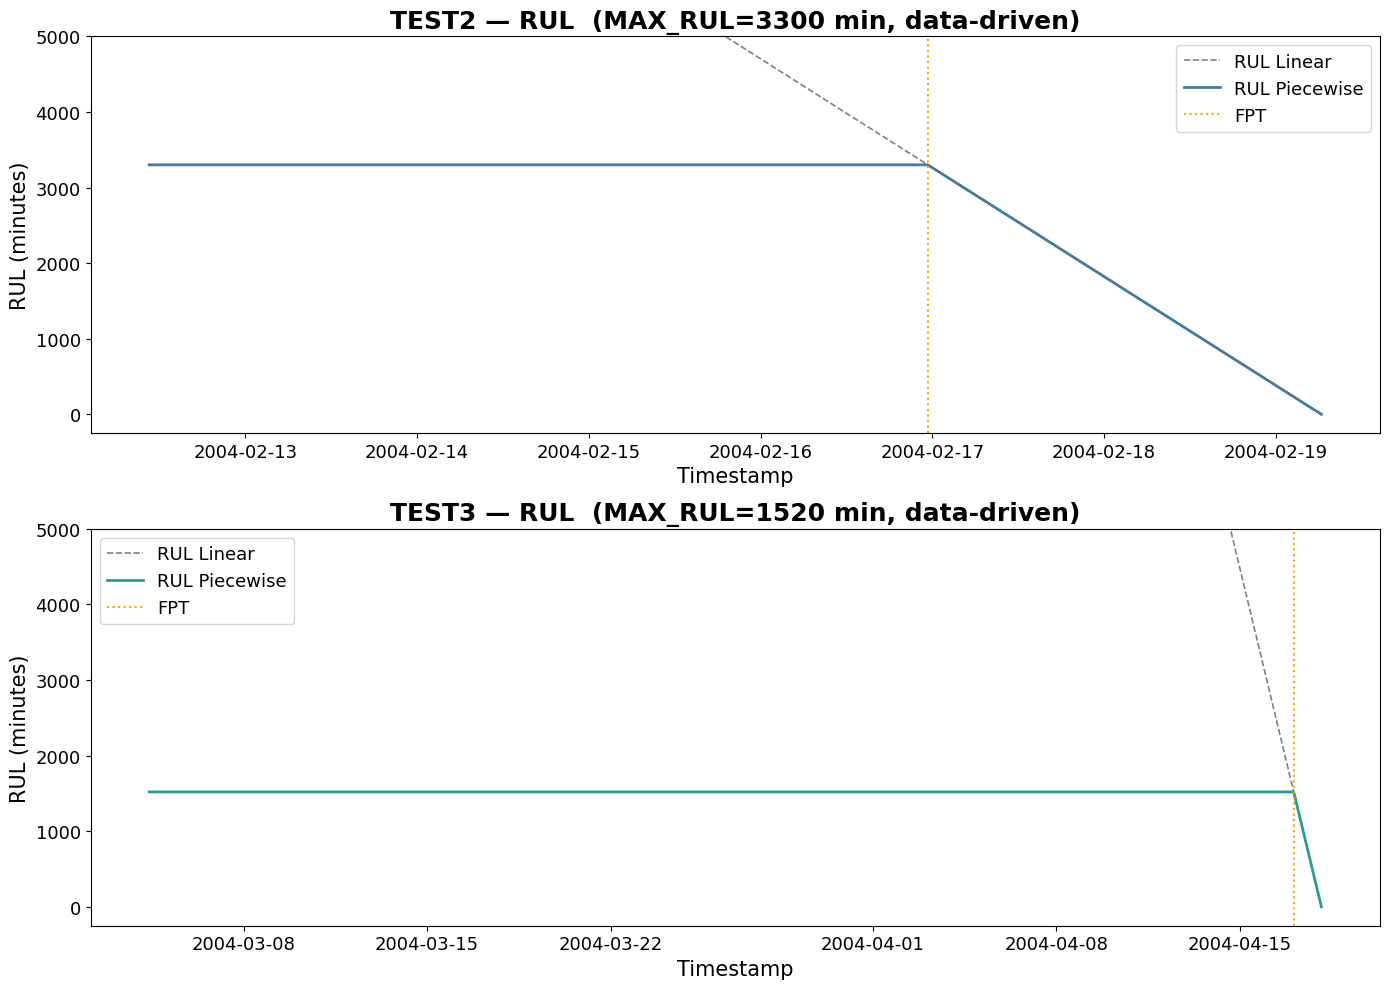

In [8]:
colors_test = {'test1': '#e63946', 'test2': '#457b9d', 'test3': '#2a9d8f'}

# set up size of label and title
TITLE_FS  = 18
LABEL_FS  = 15
TICK_FS   = 13
LEGEND_FS = 13

Y_CAP = 5000   # shared y-axis cap for both subplots (minutes)

fig, axes = plt.subplots(len(dfs_raw), 1, figsize=(14, 5*len(dfs_raw)), sharex=False)
if len(dfs_raw) == 1:
    axes = [axes]

for ax, (test_name, df) in zip(axes, dfs_raw.items()):
    max_rul = max_rul_per_test[test_name]

    ax.plot(df['timestamp'], df['rul_linear'],    color='gray', lw=1.2, ls='--', label='RUL Linear')
    ax.plot(df['timestamp'], df['rul_piecewise'], color=colors_test[test_name], lw=2, label='RUL Piecewise')
    if test_name in fpt_timestamps:
        ax.axvline(fpt_timestamps[test_name], color='orange', ls=':', lw=1.5, label='FPT')

    # Shared, fixed y-axis cap for both subplots (same scale on both)
    ax.set_ylim(-0.05 * Y_CAP, Y_CAP)

    ax.set_title(f'{test_name.upper()} — RUL  (MAX_RUL={max_rul:.0f} min, data-driven)',
                 fontweight='bold', fontsize=TITLE_FS)
    ax.set_ylabel('RUL (minutes)', fontsize=LABEL_FS)
    ax.set_xlabel('Timestamp', fontsize=LABEL_FS)
    ax.tick_params(axis='both', labelsize=TICK_FS)
    ax.legend(fontsize=LEGEND_FS)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '1_rul_labels.png'), dpi=300, bbox_inches='tight')
plt.show()

### 6. Hampel + EWMA Smoothing

In [9]:
def apply_hampel_filter(series, window_size=5, n_sigmas=3):
    # Hampel filter: detects and replaces outlier spikes using a rolling median
    rolling_median = series.rolling(window=window_size, center=True).median()
    rolling_mad    = (1.4826 *                                        # scale factor so MAD ≈ std for normal data
                      (series - rolling_median).abs()
                      .rolling(window=window_size, center=True).median())
    upper    = rolling_median + n_sigmas * rolling_mad
    lower    = rolling_median - n_sigmas * rolling_mad
    filtered = series.copy()
    mask     = (series > upper) | (series < lower)   # points outside n_sigmas of the local median
    filtered[mask] = rolling_median[mask]             # replace outliers with the local median
    return filtered.bfill().ffill()                   # fill any edge NaNs from the rolling window

# separate dict — dfs_raw is unchanged 
rul_cols  = ['rul_linear', 'rul_piecewise', 'rul_normalized', 'max_rul']
meta_cols = ['timestamp', 'filename', 'test_run'] + rul_cols

print('Applying Hampel + EWMA to dfs_smooth (dfs_raw is preserved)...')
dfs_smooth = {}
for test_name, df in dfs_raw.items():
    df_s         = df.copy()
    numeric_cols = [c for c in df_s.columns if c not in meta_cols]
    for col in numeric_cols:
        df_s[col] = apply_hampel_filter(df_s[col])
        df_s[col] = df_s[col].ewm(alpha=0.05, adjust=False).mean()
    dfs_smooth[test_name] = df_s
    print(f'  [{test_name}] smoothed {len(numeric_cols)} feature columns')

print('\n dfs_raw = original (for RUL/FPT)  |  dfs_smooth = processed (for model input)')


Applying Hampel + EWMA to dfs_smooth (dfs_raw is preserved)...
  [test2] smoothed 14 feature columns
  [test3] smoothed 14 feature columns

 dfs_raw = original (for RUL/FPT)  |  dfs_smooth = processed (for model input)


### 6b. Smoothing Verification — Before vs After


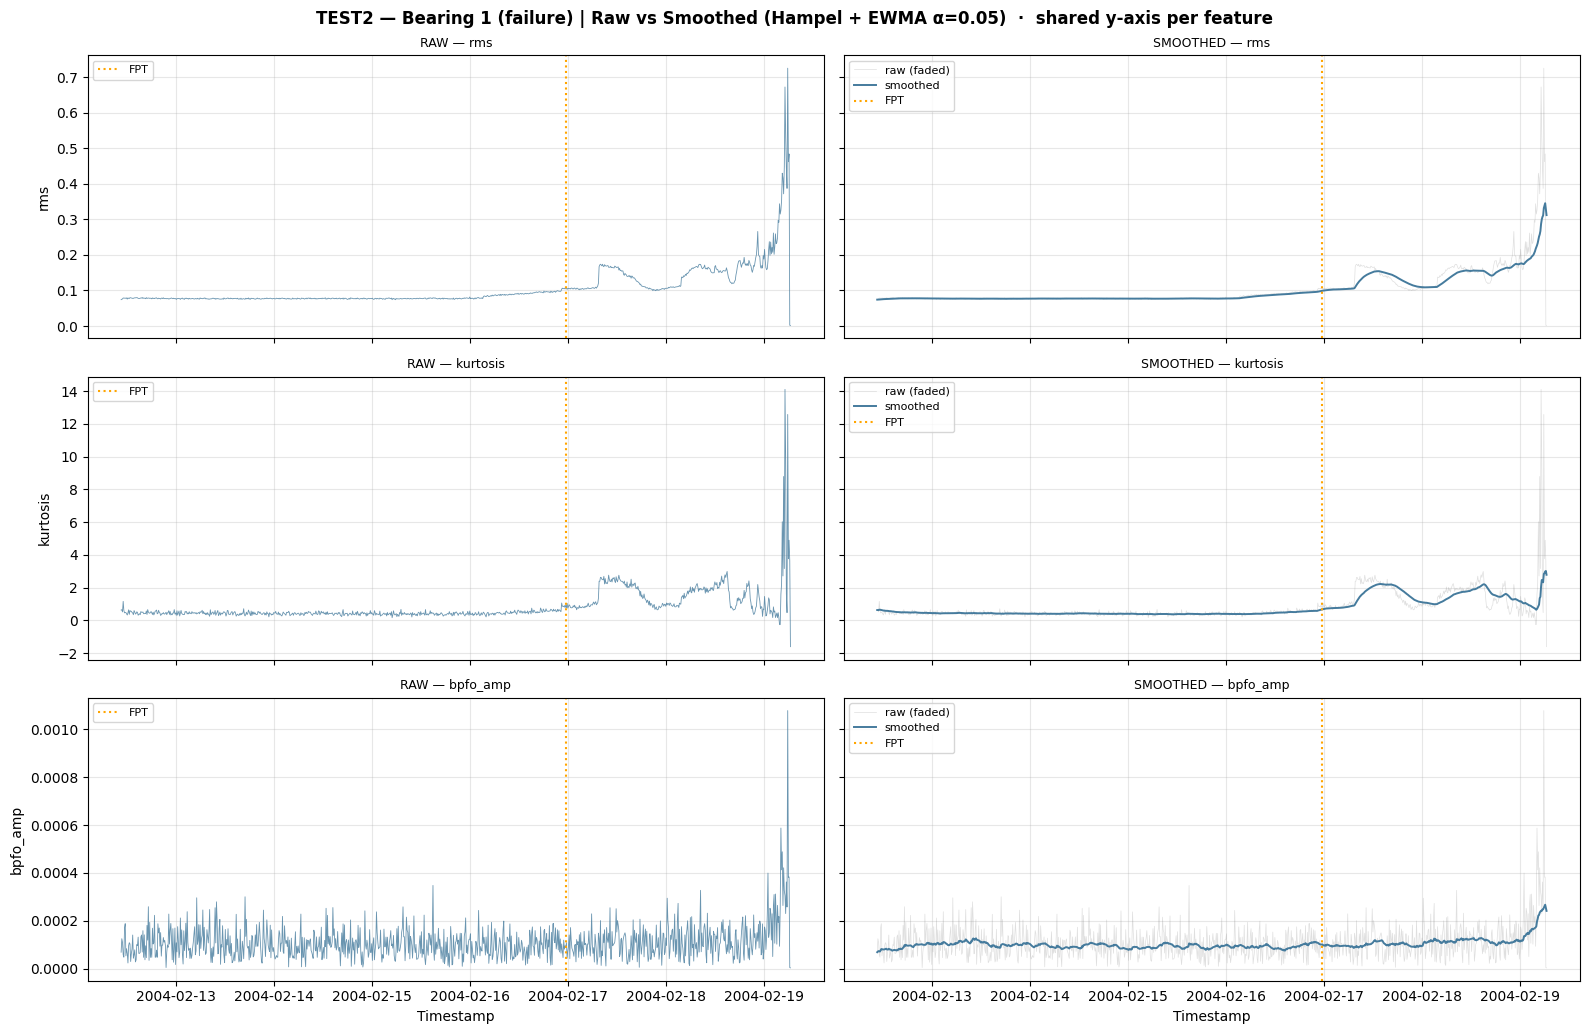

[test2] Hampel removed outliers | EWMA α=0.05 | same-scale comparison -> trend preserved, no amplification


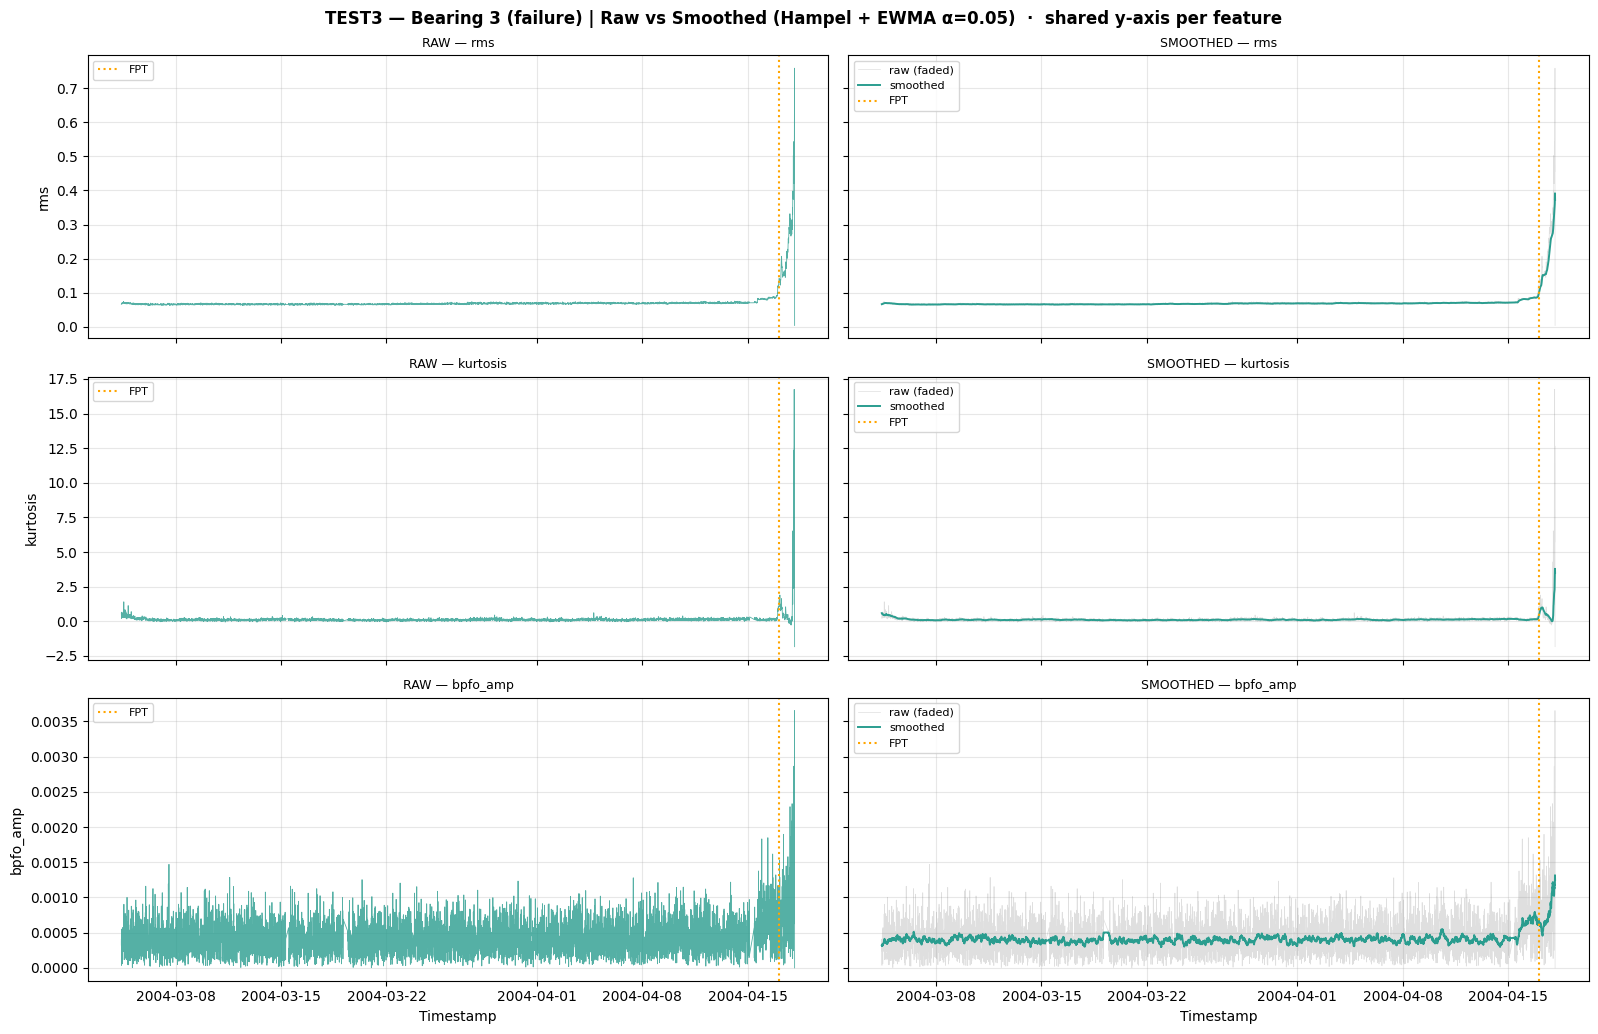

[test3] Hampel removed outliers | EWMA α=0.05 | same-scale comparison -> trend preserved, no amplification


In [10]:
# Sanity check: 3 key features for the failure bearing, raw vs smoothed, with
# matched y-axis per feature so amplitudes are directly comparable.

SMOOTH_FEATURES = ['rms', 'kurtosis', 'bpfo_amp']  # 3 most important
colors_test = {'test1': '#e63946', 'test2': '#457b9d', 'test3': '#2a9d8f'}

for test_name in dfs_raw:
    df_r = dfs_raw[test_name]
    df_s = dfs_smooth[test_name]
    bi   = FAILURE_IDX[test_name]          # failure bearing (features now unsuffixed)
    cols = [feat for feat in SMOOTH_FEATURES if feat in df_r.columns]

    fig, axes = plt.subplots(len(cols), 2, figsize=(16, 3.5 * len(cols)),
                             sharex='col', sharey='row')   # shared y per feature row
    axes = np.atleast_2d(axes)
    fig.suptitle(
        f'{test_name.upper()} — Bearing {bi+1} (failure) | Raw vs Smoothed '
        f'(Hampel + EWMA α=0.05)  ·  shared y-axis per feature',
        fontsize=12, fontweight='bold')
    c = colors_test[test_name]

    for row, col in enumerate(cols):
        # matched y-limits from BOTH raw and smoothed (honest amplitude comparison)
        both  = np.concatenate([df_r[col].values, df_s[col].values])
        lo, hi = np.nanmin(both), np.nanmax(both)
        pad    = 0.05 * (hi - lo + 1e-12)
        ylim   = (lo - pad, hi + pad)

        # RAW
        axes[row, 0].plot(df_r['timestamp'], df_r[col], color=c, lw=0.6, alpha=0.8)
        axes[row, 0].set_title(f'RAW — {col}', fontsize=9)
        axes[row, 0].set_ylabel(col)
        axes[row, 0].set_ylim(ylim)

        # SMOOTHED (with faint raw underlay so the trend match is visible)
        axes[row, 1].plot(df_r['timestamp'], df_r[col], color='gray', lw=0.5, alpha=0.25,
                          label='raw (faded)')
        axes[row, 1].plot(df_s['timestamp'], df_s[col], color=c, lw=1.4, label='smoothed')
        axes[row, 1].set_title(f'SMOOTHED — {col}', fontsize=9)
        axes[row, 1].set_ylim(ylim)

        for ax in (axes[row, 0], axes[row, 1]):
            if test_name in fpt_timestamps:
                ax.axvline(fpt_timestamps[test_name], color='orange', ls=':', lw=1.5, label='FPT')
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)

    axes[-1, 0].set_xlabel('Timestamp')
    axes[-1, 1].set_xlabel('Timestamp')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'smoothing_verify_{test_name}.png'),
                dpi=200, bbox_inches='tight')
    plt.show()
    print(f'[{test_name}] Hampel removed outliers | EWMA α=0.05 | same-scale comparison -> trend preserved, no amplification')

### 7. Health Index for All 4 Bearings

In [11]:
def construct_health_index(df, healthy_n=HEALTHY_N):
    # PCA Health Index from the failing bearing's 5 key features.
    # Direction is enforced so HI rises with degradation, and scaling uses
    # only the healthy baseline (z-score), so no future/failure info leaks in.
    feature_cols = ['rms', 'kurtosis', 'bpfo_amp', 'env_kurtosis', 'crest_factor']
    feature_cols = [c for c in feature_cols if c in df.columns]
    X         = df[feature_cols].values
    X_healthy = X[:healthy_n]

    scaler = StandardScaler().fit(X_healthy)
    pca    = PCA(n_components=1).fit(scaler.transform(X_healthy))
    hi     = pca.transform(scaler.transform(X)).flatten()

    # Enforce direction: the degraded tail must read HIGHER than the healthy head
    if hi[-healthy_n:].mean() < hi[:healthy_n].mean():
        hi = -hi

    # Leak-free scaling: z-score using HEALTHY baseline stats only
    mu, sd = hi[:healthy_n].mean(), hi[:healthy_n].std() + 1e-12
    df['hi'] = (hi - mu) / sd
    return df

print('Constructing Health Index (failing bearing, oriented, healthy-baseline scaled)')
for test_name, df in dfs_smooth.items():
    dfs_smooth[test_name] = construct_health_index(df)
    print(f'  [{test_name}] hi added | range [{dfs_smooth[test_name]["hi"].min():.2f}, '
          f'{dfs_smooth[test_name]["hi"].max():.2f}]  (healthy≈0)')

print('\n Health Index: direction enforced, no min-max future leakage.')

Constructing Health Index (failing bearing, oriented, healthy-baseline scaled)
  [test2] hi added | range [-3.38, 55.28]  (healthy≈0)
  [test3] hi added | range [-3.07, 83.56]  (healthy≈0)

 Health Index: direction enforced, no min-max future leakage.


### 8. Temporal Train / Val / Test Split

Strategy (test2 + test3 only):
- **TRAIN**: test2, split into two contiguous pieces — "before" (early healthy
  region) and "middle" (spans the FPT transition and most of the degradation,
  so the model sees both the onset of failure and how it progresses toward RUL=0).
- **VAL**: test2, split into a small **healthy-region block** and a small
  **near-failure tail** (20% of the VAL budget), so validation includes a
  genuine near-failure sample without removing that region from TRAIN.
- **TEST**: test3 (full run), held out and never seen during training.

The 20% tail ratio balances two needs: TRAIN keeps enough deep-degradation
examples that models don't have to extrapolate on test3's low-RUL samples,
while VAL still gets a real near-failure slice for reliable early stopping.

In [12]:
VAL_FRAC       = 0.20
VAL_TAIL_RATIO = 0.20  # share of the VAL budget from the near-failure tail
                       # (rest = a healthy-region block), so VAL contains both regimes

def temporal_split_mixed_val(df, fpt_idx, val_frac=VAL_FRAC, val_tail_ratio=VAL_TAIL_RATIO):
    # Builds a VAL set with both a healthy-region block and the true
    # near-failure tail, so early stopping sees a realistic mix of RUL values.
    # TRAIN keeps the two remaining contiguous pieces ("before" and "middle",
    # which spans the FPT transition). Sequences are windowed per contiguous
    # piece downstream, so no window ever bridges a removed VAL block.
    n = len(df)
    val_len      = max(int(n * val_frac), 2)
    val_tail_len = max(int(val_len * val_tail_ratio), 1)
    val_head_len = max(val_len - val_tail_len, 1)

    tail_start, tail_end = n - val_tail_len, n
    head_start = int(np.clip(fpt_idx - val_head_len, 0, max(tail_start - val_head_len, 0)))
    head_end   = head_start + val_head_len

    df_before   = df.iloc[:head_start].copy()
    df_val_head = df.iloc[head_start:head_end].copy()
    df_middle   = df.iloc[head_end:tail_start].copy()      # spans the FPT transition
    df_val_tail = df.iloc[tail_start:tail_end].copy()

    return df_before, df_middle, df_val_head, df_val_tail

splits = {}
train_segment_lens = {}   # {'test2': (len_before, len_middle)}
val_segment_lens   = {}   # {'test2': (len_healthy_block, len_tail_block)}

if 'test2' in dfs_smooth:
    fpt_idx_t2 = compute_fpt(dfs_raw['test2'], bearing_idx=FAILURE_IDX['test2'])[1]
    t2_before, t2_middle, t2_val_head, t2_val_tail = temporal_split_mixed_val(
        dfs_smooth['test2'], fpt_idx_t2)

    splits['train'] = [t2_before, t2_middle]
    splits['val']   = [t2_val_head, t2_val_tail]   # order matters — matches X_val row order after scaling

    train_segment_lens['test2'] = (len(t2_before), len(t2_middle))
    val_segment_lens['test2']   = (len(t2_val_head), len(t2_val_tail))

    print(f'  [test2] FPT idx={fpt_idx_t2}')
    print(f'    TRAIN: before={len(t2_before)}  +  middle(spans FPT)={len(t2_middle)}')
    print(f'    VAL  : healthy-block={len(t2_val_head)}  +  near-failure-tail={len(t2_val_tail)}')

if 'test3' in dfs_smooth:
    splits['test'] = dfs_smooth['test3']

df_train = pd.concat(splits['train'], ignore_index=True)
df_val   = pd.concat(splits['val'],   ignore_index=True) if 'val' in splits else pd.DataFrame()
df_test  = splits.get('test', pd.DataFrame())

print('\n=== Dataset Split Summary ===')
for name, df in [('TRAIN', df_train), ('VAL', df_val), ('TEST', df_test)]:
    if len(df):
        print(f'  {name:5s}: {len(df):5d} samples | '
              f'RUL [{df["rul_piecewise"].min():.0f}, {df["rul_piecewise"].max():.0f}] min | '
              f'Tests: {df["test_run"].unique().tolist()}')

if len(df_val):
    pct_healthy_val = (df_val['rul_normalized'] > 0.5).mean() * 100
    print(f'\n[CHECK] VAL composition: {pct_healthy_val:.0f}% healthy-side (RUL_norm>0.5) | '
          f'{100-pct_healthy_val:.0f}% near-failure-side (RUL_norm<=0.5) — should be a genuine MIX now.')

# Coverage check: does TRAIN still reach low RUL values, or is the deep
# near-failure region stuck entirely in VAL? A high train_min_rul suggests
# extrapolation risk for models without range clamping (e.g. Linear Regression).
if len(df_train):
    train_min_rul = df_train['rul_normalized'].min()
    val_min_rul   = df_val['rul_normalized'].min() if len(df_val) else float('nan')
    print(f'\n[CHECK] Lowest RUL_norm seen in TRAIN: {train_min_rul:.3f}  |  in VAL: {val_min_rul:.3f}')
    if train_min_rul > 0.15:
        print(f'TRAIN never sees RUL below {train_min_rul:.2f} — models that extrapolate '
              f'linearly (e.g. plain LinearRegression) may perform poorly on test3\'s deep '
              f'near-failure samples. Consider lowering VAL_TAIL_RATIO further, or prefer '
              f'Ridge/tree-based models for the linear baseline.')

print('[IMPORTANT] No random shuffle — temporal order preserved WITHIN each contiguous piece.')
print('[NOTE] test1 excluded — load via process_test1_for_robustness().')

  [test2] FPT idx=653
    TRAIN: before=496  +  middle(spans FPT)=292
    VAL  : healthy-block=157  +  near-failure-tail=39

=== Dataset Split Summary ===
  TRAIN:   788 samples | RUL [390, 3300] min | Tests: ['test2']
  VAL  :   196 samples | RUL [0, 3300] min | Tests: ['test2']
  TEST :  6324 samples | RUL [0, 1520] min | Tests: ['test3']

[CHECK] VAL composition: 80% healthy-side (RUL_norm>0.5) | 20% near-failure-side (RUL_norm<=0.5) — should be a genuine MIX now.

[CHECK] Lowest RUL_norm seen in TRAIN: 0.118  |  in VAL: 0.000
[IMPORTANT] No random shuffle — temporal order preserved WITHIN each contiguous piece.
[NOTE] test1 excluded — load via process_test1_for_robustness().


> ### Known limitations of this split
> - **Single training trajectory** (test2-B1): only one failure example, so
>   generalisation is limited and epistemic uncertainty is large — a core
>   motivation for the Bayesian tier.
> - **VAL is carved out, not randomly sampled**: it represents this one run's
>   healthy region and near-failure tail, but doesn't guarantee it reflects how
>   other bearings degrade.
> - Removing the two VAL blocks from TRAIN leaves small temporal gaps. Sequences
>   are windowed per contiguous piece, so no window ever spans a gap.

### 9. Feature Selection & Normalization

In [14]:
EXCLUDE_COLS = ['timestamp', 'filename', 'test_run',
                'rul_linear', 'rul_piecewise', 'rul_normalized', 'max_rul']

feature_cols = [c for c in df_train.columns if c not in EXCLUDE_COLS]
print(f'Feature columns: {len(feature_cols)}')
print(f'Sample: {feature_cols[:6]} ...')

def fit_scaler_on_healthy(df, feature_cols, healthy_n=HEALTHY_N):
    # Fits a StandardScaler on the healthy baseline portion of ONE test run.
    sc = StandardScaler()
    sc.fit(df[feature_cols].iloc[:healthy_n].values)
    return sc

scalers = {}
X_parts_train, y_parts_train = [], []
X_parts_val,   y_parts_val   = [], []

# test2: fit scaler on full test2 healthy baseline, apply to train+val portions
if 'test2' in dfs_smooth:
    sc2 = fit_scaler_on_healthy(dfs_smooth['test2'], feature_cols)
    scalers['test2'] = sc2

    # df_train keeps its [before] + [middle] row order so the windowing step
    # can re-slice X_train back into its two contiguous segments.
    mask_train = df_train['test_run'] == 'test2'
    if mask_train.sum():
        X_parts_train.append(sc2.transform(df_train.loc[mask_train, feature_cols].values))
        y_parts_train.append(df_train.loc[mask_train, 'rul_normalized'].values)

    if len(df_val):
        X_parts_val.append(sc2.transform(df_val[feature_cols].values))
        y_parts_val.append(df_val['rul_normalized'].values)

# test3: its own scaler (different run, different absolute vibration levels)
if 'test3' in dfs_smooth and len(df_test):
    sc3 = fit_scaler_on_healthy(dfs_smooth['test3'], feature_cols)
    scalers['test3'] = sc3
    X_test = sc3.transform(df_test[feature_cols].values)
    y_test = df_test['rul_normalized'].values
else:
    X_test, y_test = np.array([]), np.array([])

X_train = np.vstack(X_parts_train) if X_parts_train else np.array([])
y_train = np.concatenate(y_parts_train) if y_parts_train else np.array([])
X_val   = np.vstack(X_parts_val)   if X_parts_val   else np.array([])
y_val   = np.concatenate(y_parts_val) if y_parts_val else np.array([])

print(f'\nX_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_val  : {X_val.shape}    y_val  : {y_val.shape}')
print(f'X_test : {X_test.shape}   y_test : {y_test.shape}')

# Save scalers (test2 + test3 only; test1 scaler built on-demand in Step robustness)
scaler_path = os.path.join(OUTPUT_DIR, 'scalers.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump({'scalers': scalers, 'feature_cols': feature_cols}, f)
print(f'\n Per-test scalers saved to {scaler_path}')

Feature columns: 15
Sample: ['rms', 'peak', 'kurtosis', 'skew', 'crest_factor', 'std'] ...

X_train: (788, 15)  y_train: (788,)
X_val  : (196, 15)    y_val  : (196,)
X_test : (6324, 15)   y_test : (6324,)

 Per-test scalers saved to ./preprocessing_output\scalers.pkl


### 10. Sliding Window Sequence Generation

In [15]:
WINDOW_SIZE = 30   # 30 snapshots × 10 min = 5 hours of context
STRIDE      = 1

def create_sequences(X, y, window_size=WINDOW_SIZE, stride=STRIDE):
    # Sliding window: X_seq shape (N, window_size, n_features);
    # y_seq is the RUL at the last step of each window.
    X_seq, y_seq = [], []
    for i in range(0, len(X) - window_size + 1, stride):
        X_seq.append(X[i : i + window_size])
        y_seq.append(y[i + window_size - 1])
    if not X_seq:
        return np.array([]).reshape(0, window_size, X.shape[1] if len(X) else 0), np.array([])
    return np.array(X_seq, dtype=np.float32), np.array(y_seq, dtype=np.float32)

def _window_segments(X, y, seg_lens, window_size=WINDOW_SIZE, stride=STRIDE, tag=''):
    # Windows each contiguous segment separately (never bridging a removed
    # gap), then concatenates. seg_lens must sum to len(X).
    assert sum(seg_lens) == len(X), f'{tag}: segment lengths {seg_lens} must sum to {len(X)}'
    parts, offset = [], 0
    for j, seg_len in enumerate(seg_lens):
        if seg_len >= window_size:
            sx, sy = create_sequences(X[offset:offset+seg_len], y[offset:offset+seg_len],
                                      window_size=window_size, stride=stride)
            parts.append((sx, sy))
            print(f'  [{tag}-part{j}] sequences: {sx.shape}')
        else:
            print(f'  [{tag}-part{j}] segment too short ({seg_len} < {window_size}) — skipped')
        offset += seg_len
    if not parts:
        return np.array([]).reshape(0, window_size, X.shape[1] if len(X) else 0), np.array([])
    return (np.concatenate([p[0] for p in parts], axis=0),
            np.concatenate([p[1] for p in parts], axis=0))

print(f'Creating sequences (window={WINDOW_SIZE}, stride={STRIDE})...')

# TRAIN is [before] + [middle] (Step 8); window each piece separately so no
# window bridges the removed VAL gap.
mask_t2 = df_train['test_run'] == 'test2'
n_t2    = mask_t2.sum()

if n_t2 and 'test2' in scalers and 'test2' in train_segment_lens:
    X_t2, y_t2 = X_train[:n_t2], y_train[:n_t2]   # X_train contains test2 only in this run
    X_train_seq, y_train_seq = _window_segments(
        X_t2, y_t2, train_segment_lens['test2'], tag='train')
else:
    X_train_seq, y_train_seq = np.array([]), np.array([])

# VAL: healthy-block + near-failure-tail segments (Step 8)
if len(X_val) and 'test2' in val_segment_lens:
    X_val_seq, y_val_seq = _window_segments(
        X_val, y_val, val_segment_lens['test2'], tag='val')
else:
    X_val_seq, y_val_seq = np.array([]), np.array([])

# TEST: test3 is a single contiguous run — one window pass is correct
X_test_seq, y_test_seq = create_sequences(X_test, y_test) if len(X_test) else (np.array([]), np.array([]))

print(f'\nFinal sequence shapes:')
print(f'  X_train_seq: {X_train_seq.shape}   y_train_seq: {y_train_seq.shape}')
print(f'  X_val_seq  : {X_val_seq.shape}     y_val_seq  : {y_val_seq.shape}')
print(f'  X_test_seq : {X_test_seq.shape}    y_test_seq : {y_test_seq.shape}')

if len(y_val_seq):
    pct_healthy_val_seq = (y_val_seq > 0.5).mean() * 100
    print(f'\n[CHECK] VAL sequence composition: {pct_healthy_val_seq:.0f}% healthy-side '
          f'| {100-pct_healthy_val_seq:.0f}% near-failure-side — should be a genuine MIX now, '
          f'not ~0% like the old last-20% split.')

Creating sequences (window=30, stride=1)...
  [train-part0] sequences: (467, 30, 15)
  [train-part1] sequences: (263, 30, 15)
  [val-part0] sequences: (128, 30, 15)
  [val-part1] sequences: (10, 30, 15)

Final sequence shapes:
  X_train_seq: (730, 30, 15)   y_train_seq: (730,)
  X_val_seq  : (138, 30, 15)     y_val_seq  : (138,)
  X_test_seq : (6295, 30, 15)    y_test_seq : (6295,)

[CHECK] VAL sequence composition: 93% healthy-side | 7% near-failure-side — should be a genuine MIX now, not ~0% like the old last-20% split.


### 11. Data Distribution & RUL Imbalance Check

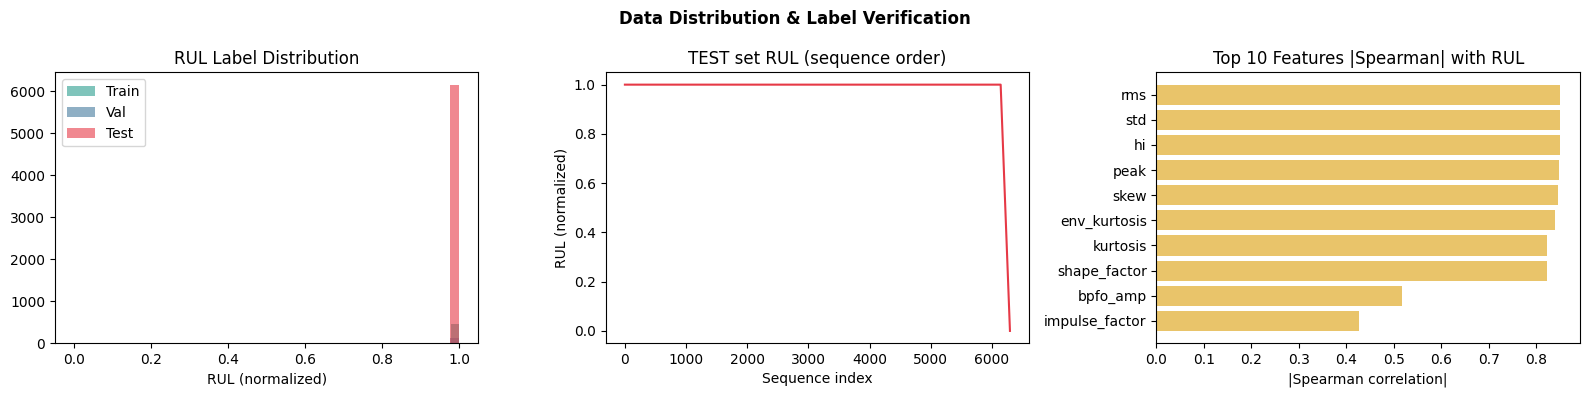

Class imbalance check (train sequences):
  RUL > 0.8 (healthy/plateau): 69.0%
  RUL < 0.2 (near failure)   : 3.7%
Large imbalance — consider sample weighting in Bayesian model loss.


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Data Distribution & Label Verification', fontweight='bold')

# Plot 1: RUL distribution per split
axes[0].hist(y_train_seq, bins=40, alpha=0.6, color='#2a9d8f', label='Train')
if len(y_val_seq):  axes[0].hist(y_val_seq,  bins=40, alpha=0.6, color='#457b9d', label='Val')
if len(y_test_seq): axes[0].hist(y_test_seq, bins=40, alpha=0.6, color='#e63946', label='Test')
axes[0].set_title('RUL Label Distribution')
axes[0].set_xlabel('RUL (normalized)')
axes[0].legend()

# Plot 2: RUL over time (test set)
if len(y_test_seq):
    axes[1].plot(y_test_seq, color='#e63946', lw=1.5)
    axes[1].set_title('TEST set RUL (sequence order)')
    axes[1].set_xlabel('Sequence index')
    axes[1].set_ylabel('RUL (normalized)')

# Plot 3: Top 10 features by Spearman correlation with RUL
if len(X_train) and len(y_train):
    corrs     = [abs(spearmanr(X_train[:, i], y_train)[0]) for i in range(X_train.shape[1])]
    top_k     = np.argsort(corrs)[-10:][::-1]
    top_names = [feature_cols[i] for i in top_k]
    top_corrs = [corrs[i] for i in top_k]
    axes[2].barh(top_names, top_corrs, color='#e9c46a')
    axes[2].set_title('Top 10 Features |Spearman| with RUL')
    axes[2].set_xlabel('|Spearman correlation|')
    axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '2_rul_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()

# imbalance warning
if len(y_train_seq):
    pct_high_rul = (y_train_seq > 0.8).mean() * 100
    pct_low_rul  = (y_train_seq < 0.2).mean() * 100
    print(f'Class imbalance check (train sequences):')
    print(f'  RUL > 0.8 (healthy/plateau): {pct_high_rul:.1f}%')
    print(f'  RUL < 0.2 (near failure)   : {pct_low_rul:.1f}%')
    if pct_high_rul > 60:
        print('Large imbalance — consider sample weighting in Bayesian model loss.')


### 12. Imbalance Handling — Stride-Aware Sub-sampling + LDS Weights

In [17]:
# Config (TRAIN ONLY)
IMBALANCE_METHOD = 'none'   # 'none' | 'stride_only' | 'lds_only' | 'both'
# 'none'         -> no subsampling, no LDS weight   (baseline)
# 'stride_only'  -> stride-aware subsampling only, weights = uniform (1.0)
# 'lds_only'     -> stride=1 (no subsampling), LDS weight only
# 'both'         -> stride-aware subsampling + LDS weight

RUL_HIGH_THR = 0.80   # windows with label > this = plateau / healthy
STRIDE_HIGH  = 5      # coarse stride in plateau  (skip near-duplicate windows)
STRIDE_LOW   = 1      # dense stride near failure (keep every window)

USE_STRIDE = IMBALANCE_METHOD in ('stride_only', 'both')
USE_LDS    = IMBALANCE_METHOD in ('lds_only', 'both')

def create_sequences_adaptive(X, y, window_size=WINDOW_SIZE,
                              stride_low=STRIDE_LOW, stride_high=STRIDE_HIGH,
                              rul_high_thr=RUL_HIGH_THR, use_stride=True):
    # RUL-aware sliding window (TRAIN only): coarse stride in the healthy
    # plateau, dense stride near failure. Rebalances without inventing or
    # deleting data, and keeps temporal order. If use_stride=False, falls
    # back to plain stride=1, so one function covers all IMBALANCE_METHOD options.
    X_seq, y_seq = [], []
    i, last = 0, len(X) - window_size
    while i <= last:
        label = y[i + window_size - 1]
        X_seq.append(X[i : i + window_size]); y_seq.append(label)
        if use_stride:
            i += stride_high if label > rul_high_thr else stride_low
        else:
            i += 1
    if not X_seq:
        return (np.array([]).reshape(0, window_size, X.shape[1] if len(X) else 0),
                np.array([]))
    return np.array(X_seq, dtype=np.float32), np.array(y_seq, dtype=np.float32)

# Keep the plain stride=1 train (from Step 10) as the BEFORE reference, then
# rebuild train according to IMBALANCE_METHOD. Val/test are not touched.
X_train_seq_before = X_train_seq.copy() if len(X_train_seq) else np.array([])
y_train_seq_before = y_train_seq.copy() if len(y_train_seq) else np.array([])

# Apply adaptive stride to the "before" and "middle" TRAIN segments
# separately (never across the removed VAL gap), then concatenate.
adaptive_parts = []
if n_t2 and 'test2' in scalers and 'test2' in train_segment_lens:
    n_before, n_middle = train_segment_lens['test2']
    X_t2, y_t2 = X_train[:n_t2], y_train[:n_t2]

    if n_before >= WINDOW_SIZE:
        adaptive_parts.append(create_sequences_adaptive(X_t2[:n_before], y_t2[:n_before], use_stride=USE_STRIDE))
    if n_middle >= WINDOW_SIZE:
        adaptive_parts.append(create_sequences_adaptive(X_t2[n_before:], y_t2[n_before:], use_stride=USE_STRIDE))

if adaptive_parts:
    X_train_seq = np.concatenate([p[0] for p in adaptive_parts], axis=0)
    y_train_seq = np.concatenate([p[1] for p in adaptive_parts], axis=0)
else:
    X_train_seq, y_train_seq = np.array([]), np.array([])

print(f'IMBALANCE_METHOD = "{IMBALANCE_METHOD}"   (stride={USE_STRIDE}, LDS={USE_LDS})')
print('1) Stride-aware sub-sampling (TRAIN only):')
print(f'   before (stride=1)                          : {X_train_seq_before.shape}  | plateau RUL>0.8 = {(y_train_seq_before>0.8).mean()*100:5.1f}%')
print(f'   after  ({"adaptive stride" if USE_STRIDE else "unchanged, stride=1  "})            : {X_train_seq.shape}  | plateau RUL>0.8 = {(y_train_seq>0.8).mean()*100:5.1f}%')

# LDS sample weights on the rebalanced train labels
from scipy.ndimage import gaussian_filter1d

def compute_lds_weights(y, n_bins=50, sigma=2.0, clip_pct=99):
    # Label Distribution Smoothing weights (Yang et al. 2021): weight is
    # proportional to 1 / smoothed label density, normalised to mean=1.
    if len(y) == 0:
        return np.array([], dtype=np.float32)
    hist, edges = np.histogram(y, bins=n_bins, range=(0.0, 1.0))
    sm = gaussian_filter1d(hist.astype(float), sigma=sigma)
    bi = np.clip(np.digitize(y, edges[:-1]) - 1, 0, n_bins - 1)
    w  = 1.0 / (sm[bi] + 1e-6)
    if clip_pct is not None:
        w = np.minimum(w, np.percentile(w, clip_pct))
    return (w / w.mean()).astype(np.float32)

if USE_LDS:
    sample_weight_train = compute_lds_weights(y_train_seq)
    sample_weight_train_flat = compute_lds_weights(y_train) if len(y_train) else np.array([], np.float32)
else:
    # LDS off -> uniform weights (mean=1), so downstream loss code that
    # multiplies by sample_weight is a no-op.
    sample_weight_train = np.ones_like(y_train_seq, dtype=np.float32)
    sample_weight_train_flat = np.ones_like(y_train, dtype=np.float32) if len(y_train) else np.array([], np.float32)

print(f'   flat train weights: n={len(sample_weight_train_flat)}  (LDS {"ON" if USE_LDS else "OFF -> uniform=1.0"})')

if len(sample_weight_train):
    near, plat = y_train_seq < 0.2, y_train_seq > 0.8
    print('\n2) Sample weights (TRAIN only):')
    print(f'   mean (≈1.0)              : {sample_weight_train.mean():.3f}')
    if near.any():
        print(f'   mean w near-fail (RUL<0.2): {sample_weight_train[near].mean():.3f}')
    if plat.any():
        print(f'   mean w plateau   (RUL>0.8): {sample_weight_train[plat].mean():.3f}')
    print(f'   → near-failure windows {"up-weighted ✓" if USE_LDS else "NOT up-weighted (LDS off)"}  (val/test stay unweighted)')

# Stride subsampling and LDS weighting are both imbalance fixes; stacking both
# on a small sequence set can over-correct. IMBALANCE_METHOD is switchable
# above so each option can be re-run and compared on RMSE / PICP / MPIW / NLL / CRPS.
if IMBALANCE_METHOD == 'both' and len(sample_weight_train) and len(sample_weight_train) < 300:
    max_w = sample_weight_train.max()
    print(f'\n[CHECK] TRAIN sequences after both fixes: n={len(sample_weight_train)}, '
          f'max LDS weight={max_w:.1f}. Small n + high max weight = possible over-correction '
          f'for the LSTM baseline -- try IMBALANCE_METHOD="stride_only" or "lds_only" and compare.')

IMBALANCE_METHOD = "none"   (stride=False, LDS=False)
1) Stride-aware sub-sampling (TRAIN only):
   before (stride=1)                          : (730, 30, 15)  | plateau RUL>0.8 =  69.0%
   after  (unchanged, stride=1  )            : (730, 30, 15)  | plateau RUL>0.8 =  69.0%
   flat train weights: n=788  (LDS OFF -> uniform=1.0)

2) Sample weights (TRAIN only):
   mean (≈1.0)              : 1.000
   mean w near-fail (RUL<0.2): 1.000
   mean w plateau   (RUL>0.8): 1.000
   → near-failure windows NOT up-weighted (LDS off)  (val/test stay unweighted)


### 12b. Imbalance Handling — Before vs After (verification)

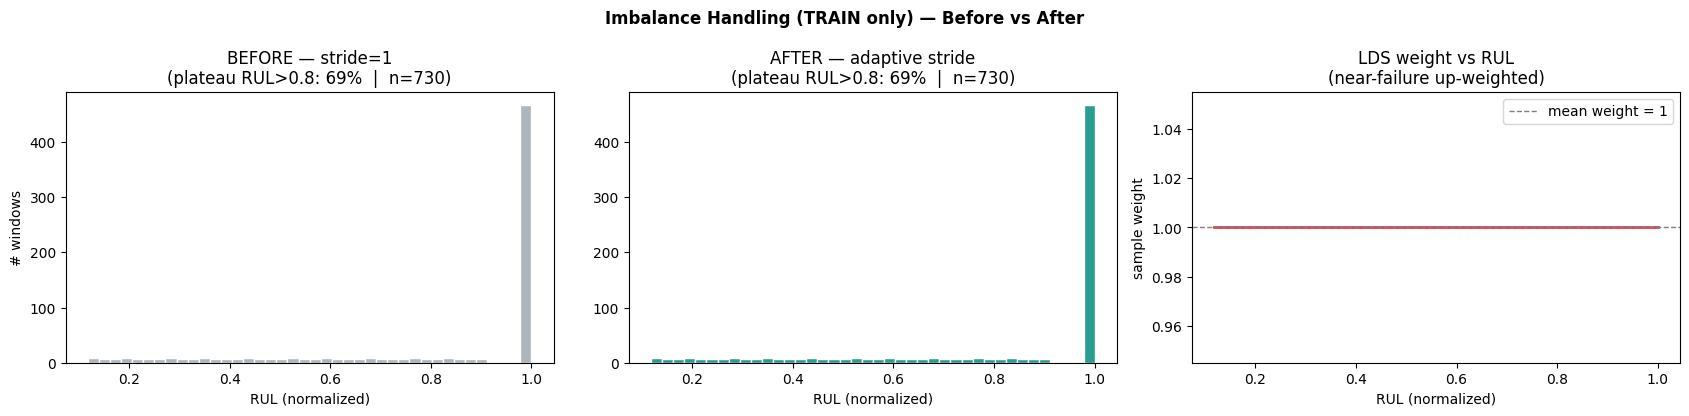

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))
fig.suptitle('Imbalance Handling (TRAIN only) — Before vs After', fontweight='bold')

# Panel 1: BEFORE (fixed stride=1)
if len(y_train_seq_before):
    axes[0].hist(y_train_seq_before, bins=40, color='#adb5bd', edgecolor='white')
    axes[0].set_title(f'BEFORE — stride=1\n(plateau RUL>0.8: {(y_train_seq_before>0.8).mean()*100:.0f}%  |  n={len(y_train_seq_before)})')
    axes[0].set_xlabel('RUL (normalized)'); axes[0].set_ylabel('# windows')

# Panel 2: AFTER (adaptive stride)
if len(y_train_seq):
    axes[1].hist(y_train_seq, bins=40, color='#2a9d8f', edgecolor='white')
    axes[1].set_title(f'AFTER — adaptive stride\n(plateau RUL>0.8: {(y_train_seq>0.8).mean()*100:.0f}%  |  n={len(y_train_seq)})')
    axes[1].set_xlabel('RUL (normalized)')

# Panel 3: LDS weight vs RUL
if len(sample_weight_train):
    order = np.argsort(y_train_seq)
    axes[2].plot(y_train_seq[order], sample_weight_train[order], color='#e63946', lw=2)
    axes[2].axhline(1.0, color='gray', ls='--', lw=1, label='mean weight = 1')
    axes[2].set_title('LDS weight vs RUL\n(near-failure up-weighted)')
    axes[2].set_xlabel('RUL (normalized)'); axes[2].set_ylabel('sample weight')
    axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '2b_imbalance_before_after.png'), dpi=300, bbox_inches='tight')
plt.show()

### 13. Export ML-Ready Dataset

In [19]:
# Sequential arrays (.npz) for temporal models (LSTM, BNN-LSTM, Transformer)
seq_path = os.path.join(OUTPUT_DIR, 'sequences.npz')
np.savez_compressed(
    seq_path,
    X_train=X_train_seq, y_train=y_train_seq,
    sample_weight_train=sample_weight_train,   # LDS weights (TRAIN only)
    X_val=X_val_seq,     y_val=y_val_seq,
    X_test=X_test_seq,   y_test=y_test_seq,
)

# Flat arrays (.npz) for non-temporal models (GP, Bayesian Ridge, RF)
flat_path = os.path.join(OUTPUT_DIR, 'flat.npz')
np.savez_compressed(
    flat_path,
    X_train=X_train, y_train=y_train,
    sample_weight_train=sample_weight_train_flat,   # LDS weights for flat models
    X_val=X_val,     y_val=y_val,
    X_test=X_test,   y_test=y_test,
)

# Raw DataFrames with metadata
df_train.to_parquet(os.path.join(OUTPUT_DIR, 'df_train.parquet'), index=False)
df_val.to_parquet(os.path.join(OUTPUT_DIR,   'df_val.parquet'),   index=False)
df_test.to_parquet(os.path.join(OUTPUT_DIR,  'df_test.parquet'),  index=False)

# Save FPT timestamps and other run metadata
meta = {
    'test_dirs':                TEST_DIRS,   # raw data folders for all 3 tests
    'test_meta':                TEST_META,   # n_channels/ch_map per test
    'feature_cols':             feature_cols,
    'n_features':               len(feature_cols),
    'window_size':              WINDOW_SIZE,
    'max_rul_per_test':         max_rul_per_test,     # data-driven, per test
    'fpt_timestamps':           {k: str(v) for k, v in fpt_timestamps.items()},
    'fpt_indices':              {k: int(v) for k, v in {  # row index in dfs_raw
        t: compute_fpt(dfs_raw[t], bearing_idx=FAILURE_IDX[t])[1]
        for t in dfs_raw}.items()},
    'failure_bearing_per_test': FAILURE_IDX,
    'bandpass_band_per_test':   BAND_PER_TEST,  # {test: (lowcut, highcut)} Hz, kurtogram-selected
    'train_samples':            len(X_train_seq),
    'val_samples':              len(X_val_seq) if hasattr(X_val_seq, '__len__') else 0,
    'test_samples':             len(X_test_seq) if hasattr(X_test_seq, '__len__') else 0,
    'healthy_n_for_scaler':     HEALTHY_N,
    'active_tests':             ACTIVE_TESTS,   # ['test2','test3'] — test1 excluded
    'feature_design':           'failing_bearing_only_aligned_14_features_plus_hi',
    'scaler_strategy':          'per_test_run_healthy_baseline',
    'sequence_strategy':        'per_test_run_then_concat',
    'imbalance_handling': {
        'method':             IMBALANCE_METHOD,   # 'none' | 'stride_only' | 'lds_only' | 'both'
        'applied_to':         'train_only',
        'stride_applied':     USE_STRIDE,
        'lds_applied':        USE_LDS,
        'train_stride_high':  STRIDE_HIGH,
        'train_stride_low':   STRIDE_LOW,
        'rul_high_threshold': RUL_HIGH_THR,
        'lds_n_bins':         50,
        'lds_sigma':          2.0,
        'reference':          'Yang et al. 2021, Delving into Deep Imbalanced Regression',
        'note':               'val/test untouched (stride=1, unweighted) for honest evaluation. '
                               'Re-run Step 12 with a different IMBALANCE_METHOD + re-export to compare.',
    },
}
with open(os.path.join(OUTPUT_DIR, 'metadata.pkl'), 'wb') as f:
    pickle.dump(meta, f)

print('Export Complete:')
print(f'  IMBALANCE_METHOD = "{IMBALANCE_METHOD}"')
n_val_seq  = len(X_val_seq)  if hasattr(X_val_seq,  '__len__') else 0
n_test_seq = len(X_test_seq) if hasattr(X_test_seq, '__len__') else 0
print(f'  sequences.npz  → train:{len(X_train_seq)} | val:{n_val_seq} | test:{n_test_seq}')
print(f'  flat.npz       → train:{len(X_train)} | val:{len(X_val) if len(X_val) else 0} | test:{len(X_test) if len(X_test) else 0}')
print('  sequences.npz  → + sample_weight_train (LDS), n={}'.format(len(sample_weight_train)))
print(f'  scalers.pkl    → per-test-run StandardScalers')
print(f'  metadata.pkl   → feature list, FPT timestamps, MAX_RUL per test')
print(f'  df_*.parquet   → full DataFrames with timestamps & RUL')
print(f'\nOutput directory: {os.path.abspath(OUTPUT_DIR)}')
print('\n→ Next: Notebook 3 — Baseline models for RUL prediction')

# Helper for robustness testing: load test1 on-demand without re-running this notebook
def process_test1_for_robustness(feature_cols, window_size=WINDOW_SIZE, healthy_n=HEALTHY_N):
    # Loads test1 (1st_test), extracts features, scales, builds sequences, and
    # returns both the flat and windowed arrays needed to evaluate all three
    # Bayesian models (Bayesian Ridge / GP use the flat arrays, MC Dropout
    # LSTM uses the sequence arrays).
    print('Loading test1 for robustness testing (flat + sequence)')
    path = TEST_DIRS['test1']
    if not os.path.exists(path):
        raise FileNotFoundError(f'test1 not found at {path}')

    # test1 fails in a different bearing (B3 inner race + B4 roller) than
    # test2/test3 (B1/B3 outer race), so its bandpass range is selected
    # separately here, on its own failing-bearing channel (Section 2b).
    if 'test1' not in BAND_PER_TEST:
        BAND_PER_TEST['test1'] = select_bandpass_band_for_test(
            path, 'test1', TEST_META['test1']['ch_map'], FAILURE_IDX['test1'])

    df_r = build_feature_dataset_for_test(path, 'test1')
    df_r, fpt_ts, max_rul = add_rul_labels(df_r, 'test1',
                                          failure_bearing_idx=FAILURE_IDX['test1'])

    # Smooth
    rul_cols  = ['rul_linear', 'rul_piecewise', 'rul_normalized', 'max_rul']
    meta_cols = ['timestamp', 'filename', 'test_run'] + rul_cols
    df_s = df_r.copy()
    for col in [c for c in df_s.columns if c not in meta_cols]:
        df_s[col] = apply_hampel_filter(df_s[col])
        df_s[col] = df_s[col].ewm(alpha=0.05, adjust=False).mean()

    # Health Index (failing bearing, oriented)
    df_s = construct_health_index(df_s)

    # Scale with its OWN healthy-baseline scaler (no leakage from test2/3)
    sc1 = fit_scaler_on_healthy(df_s, feature_cols, healthy_n=healthy_n)
    X_flat = sc1.transform(df_s[feature_cols].values)
    y_flat = df_s['rul_normalized'].values

    X_seq, y_seq = create_sequences(X_flat, y_flat, window_size=window_size)
    print(f'  test1 flat : X{X_flat.shape}  y{y_flat.shape}')
    print(f'  test1 seq  : X{X_seq.shape}  y{y_seq.shape}  (scaler fit on healthy N={healthy_n})')

    return {
        'X_flat': X_flat, 'y_flat': y_flat,
        'X_seq': X_seq, 'y_seq': y_seq,
        'df': df_s, 'scaler': sc1,
        'fpt_ts': fpt_ts, 'max_rul': max_rul,
    }

# Save the helper function's config so the robustness-testing notebook can use it
rob_meta_path = os.path.join(OUTPUT_DIR, 'robustness_config.pkl')
with open(rob_meta_path, 'wb') as f:
    pickle.dump({
        'test1_dir':      TEST_DIRS['test1'],
        'test1_meta':     TEST_META['test1'],
        'failure_idx':    FAILURE_IDX['test1'],
        'feature_cols':   feature_cols,
        'window_size':    WINDOW_SIZE,
        'healthy_n':      HEALTHY_N,
        'note': 'Call process_test1_for_robustness(feature_cols) -> dict with X_flat/y_flat/X_seq/y_seq/df'
    }, f)

Export Complete:
  IMBALANCE_METHOD = "none"
  sequences.npz  → train:730 | val:138 | test:6295
  flat.npz       → train:788 | val:196 | test:6324
  sequences.npz  → + sample_weight_train (LDS), n=730
  scalers.pkl    → per-test-run StandardScalers
  metadata.pkl   → feature list, FPT timestamps, MAX_RUL per test
  df_*.parquet   → full DataFrames with timestamps & RUL

Output directory: C:\Users\Windown\OneDrive - Aston University\1_Dissertation\1_Project_Dissertation\preprocessing_output

→ Next: Notebook 3 — Baseline models for RUL prediction
